### Var via Non-parametric methods

Here we calculate VaR using the non parametric method, specifically we assume the capital
under management is 1$ for simplicity. Then the value at risk and expected shortfall can 
be calculated as 

$$VaR(1-\alpha) = M q(\alpha)$$

where q means quantile, while the expected shortfall is given by

$$ES(1-\alpha) = M \frac{\sum_{i=1}^{n} r_i I(r_{i}<q(\alpha))}{\sum_{i=1}^{n} I(r_{i}<q(\alpha))}$$

Where $I(x)$ is the indicator function, it is one if the statement x is true, 0 otherwise

In [14]:

import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import math
import seaborn
import datetime
from datetime import date

from scipy.stats import norm
from tabulate import tabulate

# read the data for the required stock
start_date = datetime.date(2015,1,1)
end_date = datetime.date(2021,12,31)
ticker=yf.Ticker("AMZN")
data =ticker.history(start=start_date, end=end_date)['Close']
stock_returns = data.pct_change()
stock_returns= stock_returns.dropna()

VaR_90=np.quantile(stock_returns, .1)
VaR_95=np.quantile(stock_returns, .05)
VaR_99=np.quantile(stock_returns, .01)

table_VaR = [['90%', VaR_90], ['95%', VaR_95], ['99%', VaR_99]]
print(tabulate(table_VaR, headers=['Confidence level', 'VaR']))

ES_90 = stock_returns[stock_returns < VaR_90].mean()
ES_95 = stock_returns[stock_returns < VaR_95].mean()
ES_99 = stock_returns[stock_returns < VaR_99].mean()

table_ES = [['90%', ES_90], ['95%', ES_95], ['99%', ES_99]]
print(tabulate(table_ES, headers=['Confidence level', 'ES']))

Confidence level           VaR
------------------  ----------
90%                 -0.0181905
95%                 -0.027938
99%                 -0.0523781
Confidence level            ES
------------------  ----------
90%                 -0.0319935
95%                 -0.0416977
99%                 -0.0634476


As simple as that to contrast to what a parametric method could have looked like, we plot a histogram of returns

<function matplotlib.pyplot.show(close=None, block=None)>

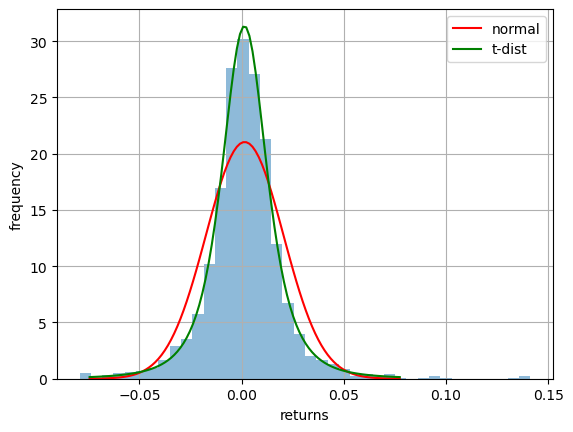

In [15]:
from scipy.stats import t
mean = np.mean(stock_returns)
stdev = np.std(stock_returns)
nu, mu, sigma = t.fit(stock_returns)
stock_returns.hist(bins=40,density=True,
                        histtype='stepfilled', alpha=0.5)
x=np.linspace(mean-4*stdev, mean + 4*stdev, 100)
plt.plot(x,norm.pdf(x, mean, stdev), "r", label="normal")
plt.plot(x,t.pdf(x, nu,mu, sigma), "g", label="t-dist")
plt.xlabel('returns')
plt.ylabel('frequency')
plt.legend(loc="upper right")
plt.show

### Var via Parametric methods

The problem with non-parametric methods is that the amount of data needed for 
them to be reliable grows as $\alpha$ diminishes. This is because more data is
needed to estimate smaller quantiles. This makes nonparametric methods not
ideal when one wishes to have a small expected shortfall. Let us repeat this
using a parametric method.  For a parametric technique the VaR can be estimated
via

$$VaR(1-\alpha) = M F^{-1}(\alpha,\theta)$$

Where $\theta$ are the parameters, of the parametric model assumed. Let us
assume that the underlying distribution, for the historical returns

$$F(r,\theta) = \phi(\mu,\sigma^{2})$$

where $\phi$ is the cumulative distribution function for a normal distribution,
while $\mu$ and $\sigma$ are its means and standard deviations needed to 
describe it. For a normal distribution then 

$$VaR(1-\alpha) =(\mu +\sigma q(\alpha) )M$$


In [18]:
import scipy.stats as st
q_010 = st.norm.ppf(.10) # quantiles are obtained via ppf 
q_005 = st.norm.ppf(.05)
q_001 = st.norm.ppf(.01)

VaR_90 = mean + stdev*q_010
VaR_95 = mean + stdev*q_005
VaR_99 = mean + stdev*q_001

table_VaR = [['90%', VaR_90], ['95%', VaR_95], ['99%', VaR_99]]
print(tabulate(table_VaR,
headers=['Confidence level (normal)', 'VaR']))


Confidence level (normal)           VaR
---------------------------  ----------
90%                          -0.0227621
95%                          -0.0296506
99%                          -0.0425723


The expected shortfall formula is a bit more complicated, but reasonable

$$ES(1-\alpha) = M \left( \mu - \sigma \left(\frac{\phi_{pdf}(\Phi_{cdf}^{-1}(\alpha))}{\alpha}\right)\right)$$

In [21]:
ES_90 = mean - stdev*(norm.pdf(q_010)/.10)
ES_95 = mean - stdev*(norm.pdf(q_005)/.05)
ES_99 = mean - stdev*(norm.pdf(q_001)/.01)

table_ES = [['90%', ES_90], ['95%', ES_95], ['99%', ES_99]]
print(tabulate(table_ES,
headers=['Confidence level (normal)', 'ES']))

Confidence level (normal)            ES
---------------------------  ----------
90%                          -0.0317387
95%                          -0.0375735
99%                          -0.0489975


From the Histogram we could have guessed that the student t distribution was a better parametric model , 
so let us repeat our calculations with that one. In this case

$$VaR(1-\alpha)= M (\mu + \sigma F^{-1}_{\nu}(\alpha))$$

and

$$ES(1-\alpha)= M (\mu - \sigma \frac{f_{\nu}(F^{-1}_{\nu}(\alpha))}{\alpha} \frac{\nu + (F_{\nu}^{-1}(\alpha))^{2}}{\nu-1})$$

where $f_{\nu}$ us the pdf and $F_{\nu}$ the CDF. We need to estimate the three parameters
$\sigma,\mu,\nu$ we do so via fit (scipy includes a special fit for the t distribution).

In [22]:
from scipy.stats import t
from array import array

stock_ret_array = stock_returns.to_numpy()
nu, mu, sigma = t.fit(stock_ret_array)
##############
t.fit(stock_ret_array)

(2.939580926969484, 0.0014228719631043983, 0.01170465912334697)

In [23]:
q_010 = st.t.ppf(.10, nu, mu, sigma)
q_005 = st.t.ppf(.05, nu, mu, sigma)
q_001 = st.t.ppf(.01, nu, mu, sigma)

VaR_90 = q_010
VaR_95 = q_005
VaR_99 = q_001

table_VaR = [['90%', VaR_90], ['95%', VaR_95], ['99%', VaR_99]]
print(tabulate(table_VaR,
headers=['Confidence level(t-dist.)', 'VaR']))

Confidence level(t-dist.)           VaR
---------------------------  ----------
90%                          -0.0178532
95%                          -0.0263548
99%                          -0.0526079


### Var via MonteCarlo

This is basically an extension of the parametric approach. In essence the simplest
version of it. We simply start with a paramteric model and simulate a number of
random variables of patters of prices, over an estimated period of time, then 
we calculate the required percentiles and we are done.  

In [24]:
n_sims = 1_000_000
sim_returns = np.random.normal(mean, stdev, n_sims)
sim_VaR = np.percentile(sim_returns, 1)
print('1-day simulated VaR is ', sim_VaR)


1-day simulated VaR is  -0.0426289115550463


This was particularly simple, and not iluminatting, in principle does not gives 
us anything new at this stage, However, simulating different trajectories allows us
to introduce different events manually, something we could not do with the other methods

Assume for now we have $m$ assets in our portfolio, an that these are approximately
linearly priced (this means the stock value is a linear function of its price). This 
is sometimes called a linear portfolio and can be described by 

- $S$ which is an $m \times 1$ vector of market prices and interest rates
- $\Delta t$ the time interval where we would like to asses risk 
- $V(S,t)$ the value of our portfolio at time $t$ and market prices $S$
- $L=V(S,t)-V(S+\Delta S,t+\Delta t) $ is the value lost from the portfolio over 
$\Delta t$
- With a linear portfolio, $\Delta V = \beta^{T} \Delta S$ where $\beta$ is called
a vector of sensitivities


if one of the assets, say $W$ is a derivative, then

$$
\Delta W \approx    \frac{\partial W}{\partial t} \Delta t  +  \frac{\partial W}{\partial S} \Delta S + \frac{1}{2} \frac{\partial^{2} W}{\partial S^{2}} (\Delta S)^{2}=
 \frac{\partial W}{\partial t} \Delta t  +  \beta \Delta S + \frac{1}{2} \Gamma(\Delta S)^{2}
$$

where $\Gamma=\frac{\partial^{2} W}{\partial S^{2}}$,$\beta =\frac{\partial W}{\partial S}$. If the first and last terms are small it can be linearly approximated. 

Let us assume we have normally distributed returns, using linearity as an 
assumption we have 

$$\frac{V_{t}}{V_{t-1}} = \beta^{T} r_{t}$$

That means $$\frac{V_{t}}{V_{t-1}}$$ is normally distributed for a linearly 
priced portfolio, so that we can estimate the VaR as 

$$VaR(\alpha) = \beta^{T} \mu +q(\alpha) \sqrt{\beta^{T}\Sigma \beta}$$

The method just outlined is also known as the variance-covariance method. The 
essential advantage of this method is that it allows to introduce correlations 
between assets. It can be difficult to implement if we don't use linearity as 
an assumption, but it is doable. 

**Below we do not calculate VaR but only the simulation of the multivariate 
distribution**


In [1]:
import numpy as np
# specify mean and variance-covariance matrix
mu = [1, 2]
Sigma = [[5, 1], [1, 4]]
n_sim = 100000
sim_mult_normal = np.random.multivariate_normal(mu, Sigma, n_sim)

In [3]:
# simulating from multivariate t distribution.
import numpy as np
from scipy.stats import chi

def multivariate_t_rvs(m, S, df=1, n=1):
    m = np.asarray(m)  # procedure requires a type array
    d = len(m)     # distribution is d-dimensional
    v = np.random.chisquare(df, n)
    z = np.random.multivariate_normal(np.zeros(d),S,(n,))
    return m + z*np.sqrt(df/v)[:,None]

# using the function:
n=5  # number of simulations
df=3 # degrees of freedom
mu = [1, 2, -1]
Omega = [[1, .5, -0.3], [.5, 2, 0], [-0.3, 0, 2]]
simulated_values = multivariate_t_rvs(mu, Omega, df, n)